# Imports

In [53]:
from pathlib import Path
import shutil

import ccdproc
import astropy.io.fits as fits

import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import astroalign as aa
import math
from astropy.io.fits import Header

# Check Environment

Check if science and flat directories exist and are populated:

In [54]:
directory_names = ["science", "flats"]
project_root = Path.cwd()

for directory_name in directory_names:
    target_dir = project_root / "data" / directory_name
    if not target_dir.exists() or not target_dir.is_dir():
        raise RuntimeError(f"Directory {target_dir} does not exist")
    if not any(target_dir.iterdir()):
        raise RuntimeError(f"Directory {target_dir} contains no files")

Generate and clean necessary directories:

In [55]:
directory_names = ["flat-fielded", "aligned", "combined", "masters"]
project_root = Path.cwd()

for directory_name in directory_names:
    target_dir = project_root / "generated" / directory_name
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

PermissionError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\ObservationalAstronomy\\generated\\flat-fielded\\science1Vf.fits'

# Helpers

In [ ]:
def get_v_min_max(*fits_data):
    return min(np.percentile(data.data - data.mean(), 5) for data in fits_data), max(
        np.percentile(data.data - data.mean(), 95) for data in fits_data)

In [ ]:
def plot_fits(fits_data, titles, cbar_label):
    n = len(fits_data)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), constrained_layout=True)

    if n == 1:
        axes = [axes]

    processed = [fd - fd.mean() for fd in fits_data]
    vmin, vmax = get_v_min_max(*processed)

    for ax, data, title in zip(axes, processed, titles):
        im = ax.imshow(data, vmin=vmin, vmax=vmax, cmap='magma')
        ax.set_title(title)

    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.04, pad=0.02)
    cbar.set_label(cbar_label)
    plt.show()

# Combine flats

Combine helper function:

In [ ]:
def combine_flats(filenames, save_name):
    images = []
    for f in filenames:
        hdr = fits.getheader(f)
        data = fits.getdata(f) + 1.0 * hdr['PEDESTAL']
        data /= data.mean()
        images.append(ccdproc.CCDData(data, unit=u.adu))

    flat = ccdproc.combine(images, method='average')
    fits.writeto(f'./generated/masters/{save_name}.fits', flat.data, overwrite=True)
    return flat.data

Combine V and r flats:

In [ ]:
flat_V = combine_flats(filenames=['./data/flats/flat%dV.FIT' % j for j in range(1, 11)], save_name="masterFlatV")
flat_r = combine_flats(filenames=['./data/flats/flat%dr.FIT' % j for j in range(1, 11)], save_name="masterFlatr")

Assert correct normalisation:

In [ ]:
assert flat_V.mean() == 1.0, "V master flat is not normalised!"
assert flat_r.mean() == 1.0, "r master flat is not normalised!"

Plot results:

In [ ]:
plot_fits([flat_V, flat_r, flat_V - flat_r], ["Master V", "Master r", "Difference map (V- r)"], "Normalised Sensitivity")

Sensitivity variation analysis:

In [ ]:
print("Sensitivity variation analysis:")
print(f"FlatV max: {np.max(flat_V.data) - np.min(flat_V.data)} | std dev: {np.std(flat_V.data)} ")
print(f"Flatr max: {np.max(flat_r.data) - np.min(flat_r.data)} | std dev: {np.std(flat_r.data)} ")

# Make Flat Fielded

Make helper function:

In [ ]:
def make_flat_fielded(suffix, master_flat):
    for j in range(1, 11):
        file_in = f"./data/science/science{j}{suffix}.FIT"
        file_out = f"./generated/flat-fielded/science{j}{suffix}f.fits"
        print("Processing file: %s -> %s" % (file_in, file_out))

        hdr = fits.getheader(file_in)
        data = fits.getdata(file_in) + 1.0 * hdr['PEDESTAL']

        data /= master_flat

        hdr.add_comment("Pedestal corrected")
        hdr.add_comment("Flat-fielded with master_flat")
        hdr.add_comment("Saved as 32-bit integer")

        fits.writeto(file_out, np.int32(data), hdr, overwrite=True)

Make flat fielded:

In [ ]:
make_flat_fielded("V", fits.getdata("./generated/masters/masterFlatV.fits"))
make_flat_fielded("r", fits.getdata("./generated/masters/masterFlatr.fits"))


Plot results:

In [ ]:
INDEX = 3
raw = fits.getdata(f"./data/science/science{INDEX}r.FIT")
flat_fielded = fits.getdata(f"./generated/flat-fielded/science{INDEX}rf.fits")
plot_fits([raw, flat_fielded], ["Raw", "Flat Fielded"], "Normalised pixel value (corrected)")

# Align

Define helper function:

In [ ]:

# Read target image
def align(suffix, datatarg):
    fits.writeto(f"./generated/aligned/science1{suffix}t.fits", datatarg, overwrite=True)

    for j in range(2, 11):
        file_in = f"./generated/flat-fielded/science{j}{suffix}.fits"
        file_out = f"./generated/aligned/science{j}{suffix}t.fits"

        datasrc = fits.getdata(file_in)

        T, (source_pos_array, target_pos_array) = aa.find_transform(datasrc, datatarg)
        print(f"Image name = {file_in}  shifts= {T.translation} rot= {T.rotation * 180 / math.pi}  scale = {T.scale}")

        assert abs(T.rotation * 180 / math.pi) < 0.01, "Rotation deviates too much!"
        assert abs(T.scale - 1) < 0.0002, "Scale deviates too much!"

        data_tran, footprint = aa.apply_transform(T, datasrc, datatarg)
        fits.writeto(file_out, data_tran, overwrite=True)


Align images:

In [ ]:
datatarg = fits.getdata(f'./generated/flat-fielded/science1Vf.fits')
align("Vf", datatarg)
align("rf", datatarg)

# Combine

Helper function for combining:

In [ ]:
def combine_aligned(suffix):
    filenames = [f"./generated/aligned/science{j}{suffix}ft.fits" for j in range(1, 11)]
    images = [ccdproc.CCDData(fits.getdata(f), unit=u.adu) for f in filenames]
    sciAvg = ccdproc.combine(images, method='average')

    header = Header(sciAvg.meta)

    # Save the output
    fits.writeto(f'./generated/combined/{suffix}cmb.fits', sciAvg.data, header, overwrite=True)


Combine:

In [ ]:
combine_aligned("V")
combine_aligned("r")

Plot results:

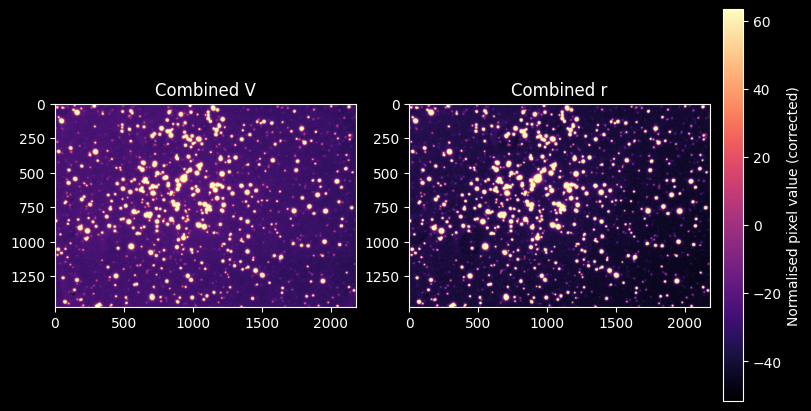

In [56]:
combinedV = fits.getdata(f"./generated/combined/Vcmb.fits")
combinedr = fits.getdata(f"./generated/combined/rcmb.fits")
plot_fits([combinedV, combinedr], ["Combined V", "Combined r"], "Normalised pixel value (corrected)")